### **О чём анализ?**
Разбираем 2039 вакансий трёх крупных работодателей — **Яндекса**, **Сбера** и **Газпром нефти**. Это не абстрактный обзор рынка, а прикладной разбор: кого нанимают, на каких условиях и как это связано с реальными задачами бизнеса.

### **Основные выводы (TL;DR)**

*   **Яндекс** — ищет готовых опытных разработчиков. Зарплаты высокие, но соцпакет поскромнее, чем у конкурентов. Ставка на сложность задач и бренд.
*   **Сбер** — берёт новичков, учит и даёт максимум льгот. Гибкий график и премии — почти в каждой вакансии. Похоже на осознанную стратегию привлечения массового персонала.
*   **Газпром нефть** — предлагает лучшие условия для начинающих инженеров и производственников. Senior-позиции почти не выкладывают в открытый доступ, скорее растят их внутри.

**Дальше:** пять разделов с графиками и цифрами — от географии до бенефитов. В конце — сводка выводов и трендов.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
project_root = Path.cwd().parent
file_path = project_root / 'data' / 'processed' / 'vacancies_processed.csv'
df = pd.read_csv(file_path)
df.head()

,id,company,company_id,professional_role,salary_from,salary_to,salary_currency,experience,city,published_at,benefit_ДМС,benefit_Обучение,benefit_Гибкий график,benefit_Спорт,benefit_Питание,benefit_Ивенты,benefit_Жилищные программы,benefit_Пенсия,benefit_Премии
0,130611278,Яндекс,1740,"Менеджер по маркетингу, интернет-маркетолог",NaN,NaN,NaN,От 1 года до 3 лет,Москва,2026-02-19T14:28:54+0300,True,True,False,True,True,True,False,False,True
1,130644713,Яндекс,1740,"Менеджер по логистике, менеджер по ВЭД",NaN,NaN,NaN,От 3 до 6 лет,Москва,2026-02-20T14:18:05+0300,True,False,True,True,False,True,False,False,True
2,130622063,Яндекс,1740,Другое,NaN,NaN,NaN,Нет опыта,Москва,2026-02-19T19:57:18+0300,False,True,True,False,True,True,False,False,False
3,130601430,Яндекс,1740,Специалист по подбору персонала,NaN,NaN,NaN,От 1 года до 3 лет,Москва,2026-02-19T11:41:52+0300,False,True,True,False,False,False,False,False,False
4,130540229,Яндекс,1740,Менеджер по персоналу,NaN,NaN,NaN,От 1 года до 3 лет,Москва,2026-02-17T17:25:38+0300,True,True,True,False,False,False,False,False,False


## **1. Распределение вакансий по городам**
Оценим распределение вакансий по городам при помощи столбчатой диаграммы

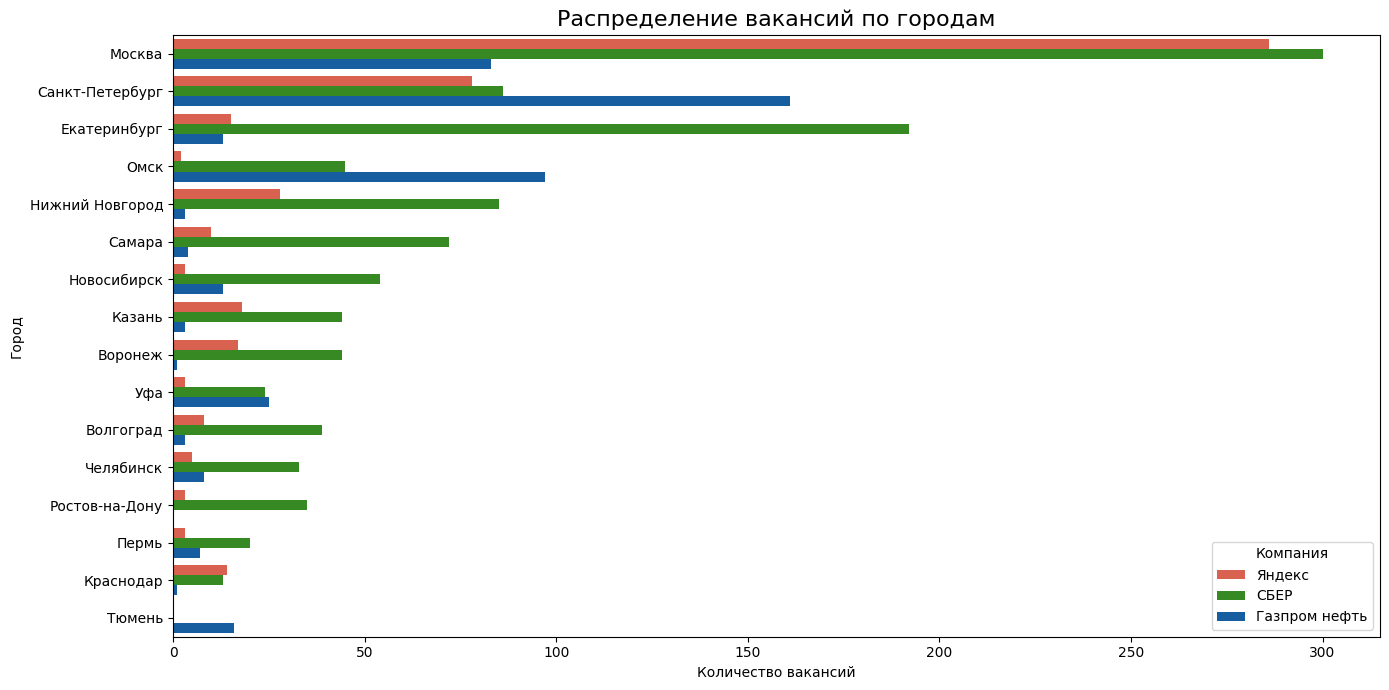

In [2]:
top_cities = df['city'].value_counts().head(16).index.tolist()
df_top_cities = df[df['city'].isin(top_cities)]

company_colors = {
    'Яндекс': '#f05038',  # красный
    'СБЕР': '#2D9B12',  # зеленый
    'Газпром нефть': '#005eb8',  # синий
}

# Построение столбчатой диаграммы
plt.figure(figsize=(14, 7))
sns.countplot(data=df_top_cities, y='city', hue='company',
              order=df_top_cities['city'].value_counts().index, palette=company_colors)
plt.title('Распределение вакансий по городам', fontsize=16)
plt.xlabel('Количество вакансий')
plt.ylabel('Город')
plt.legend(title='Компания')
plt.tight_layout()
plt.show()

Москва ожидаемо доминирует по количеству вакансий, за ней идут Санкт-Петербург и Екатеринбург.
Сбер преобладает в большинстве регионов кроме Санкт-Петербурга, Омска, Уфы, Тюмени, где преобладает Газпром нефть.
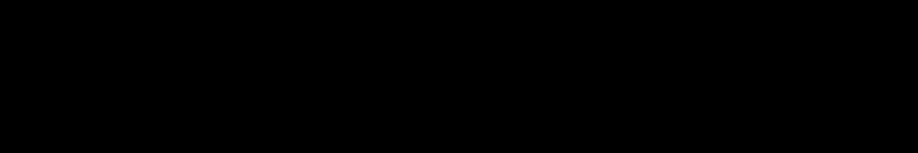
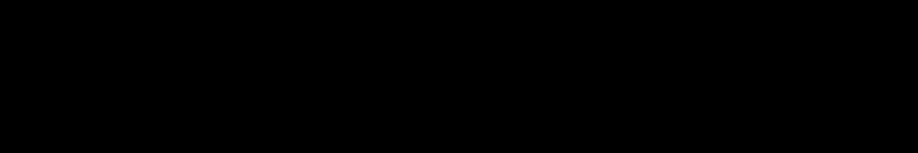
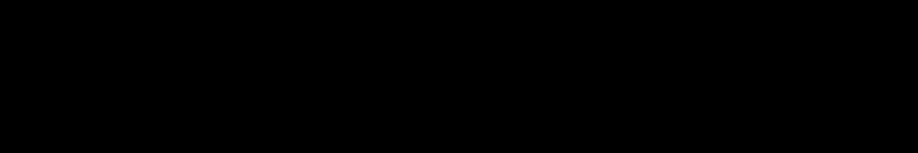
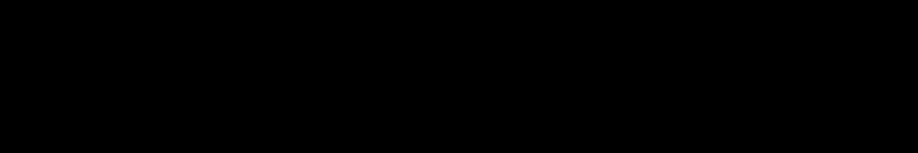
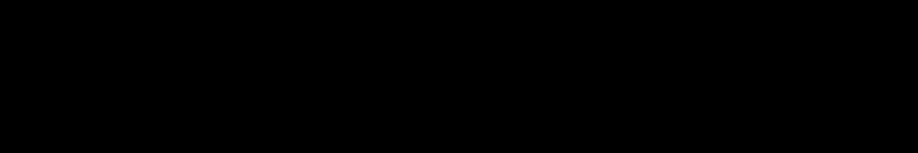
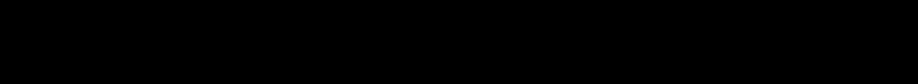

## **2. Зарплаты по опыту и компаниям**
При помощи box-plot оценим зависимость зарплаты от стажа. Категории стажа те же, что используются в вакансиях на hh.ru

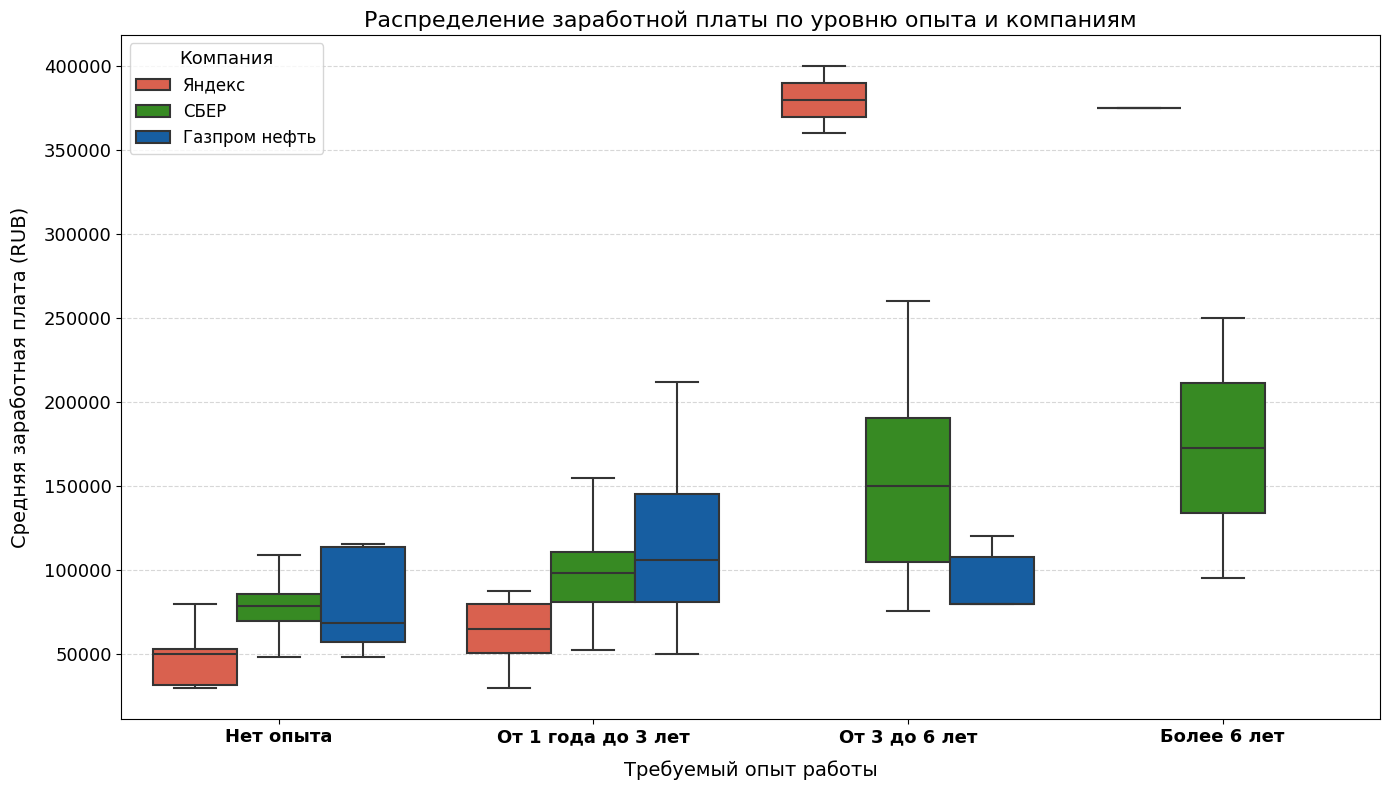

In [20]:
# Среднее по двум колонкам с учетом пропусков (NaN игнорируются автоматически)
df['salary_avg'] = df[['salary_from', 'salary_to']].mean(axis=1)
# Убираем вакансии без указания зарплаты для этого анализа
df_salary = df[df['salary_avg'].notna()].copy()

# Упорядочим категории стажа
experience_order = ['Нет опыта', 'От 1 года до 3 лет', 'От 3 до 6 лет', 'Более 6 лет']
df_salary['experience'] = pd.Categorical(df_salary['experience'], categories=experience_order, ordered=True)

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_salary, x='experience', y='salary_avg', hue='company',
            showfliers=False, palette= company_colors, linewidth = 1.5) # Убираем выбросы для наглядности
plt.title('Распределение заработной платы по уровню опыта и компаниям', fontsize=16)
plt.xlabel('Требуемый опыт работы', fontsize=14, labelpad=10)
plt.ylabel('Средняя заработная плата (RUB)', fontsize=14, labelpad=10)
plt.legend(title='Компания', title_fontsize=13, fontsize=12, loc='best')
plt.xticks(fontsize=13, weight='bold')
plt.yticks(fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Выводы:
1. **Яндекс** делает основную ставку на специалистов уровня "3-6 лет", предлагая им максимальные зарплаты и широкие возможности роста. Для топ-уровня переходит к индивидуальным переговорным условиям.
2. **Сбербанк** демонстрирует наиболее сбалансированную и формализованную систему с постепенным ростом медиан, но при этом сохраняет гибкость (длинные усы) на ключевых уровнях "1-3" и "3-6 лет".
3. **Газпром нефть** предлагает лучшие условия на входе "нет опыта" и "1-3 года", но проигрывает конкурентам на уровне "3-6 лет", что может быть стратегическим решением, если компания делает ставку на удержание собственных кадров, а не на внешний найм на этом этапе.
4. **Отсутствие вакансий для senior**-уровня у Газпром нефти и особенности их представленности у Яндекса имеют 2 объяснения: компании используют другие каналы привлечения или зарплаты для самых опытных специалистов не указываются.
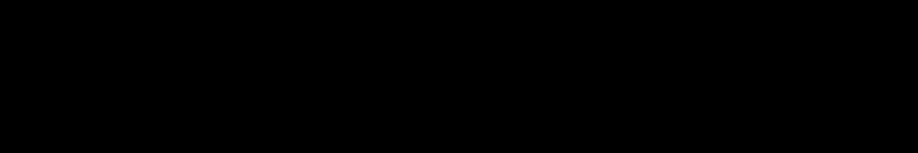

## **3. Опыт по компаниям**
Нужно проработать проблему с отсутствием вакансий для senior. Построим распределение опыта внутри компании

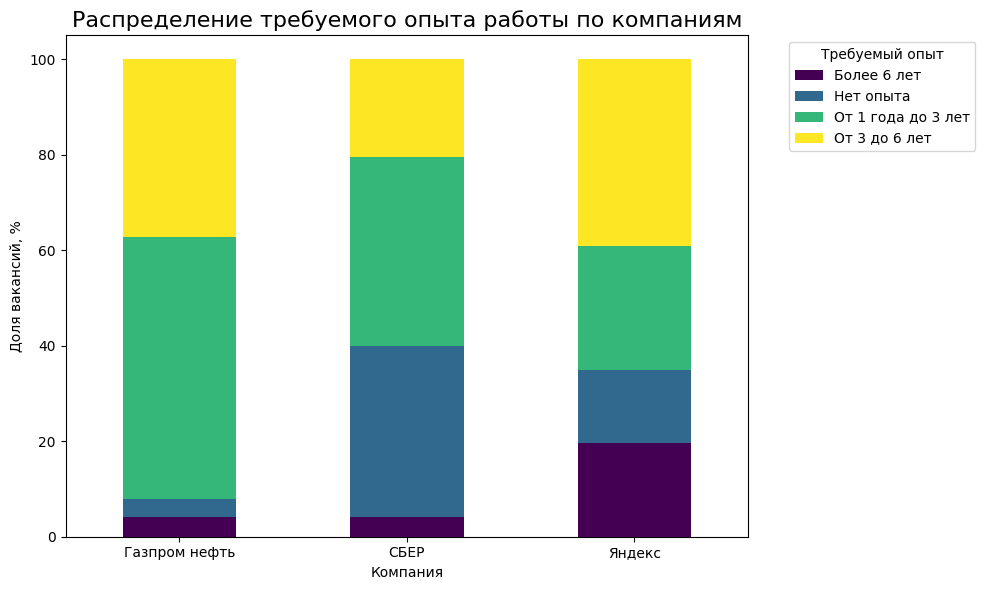

In [17]:
# Используем нормированную столбчатую диаграмму, чтобы увидеть пропорции внутри компании
experience_ct = pd.crosstab(df['company'], df['experience'], normalize='index') * 100
experience_ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Распределение требуемого опыта работы по компаниям', fontsize=16)
plt.xlabel('Компания')
plt.ylabel('Доля вакансий, %')
plt.legend(title='Требуемый опыт', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Выводы:
1. **Вакансии для senior**-уровня есть у всех, Яндекс ищёт их чаще других.
2. **Газпром нефть** делает ставку на middle специалистов, до 90% вакансий.
3. **СБЕР** лидер в поиске новичков без опыта и с опытом до 3 лет.

Построим тепловую карту самая популярная категория опыта

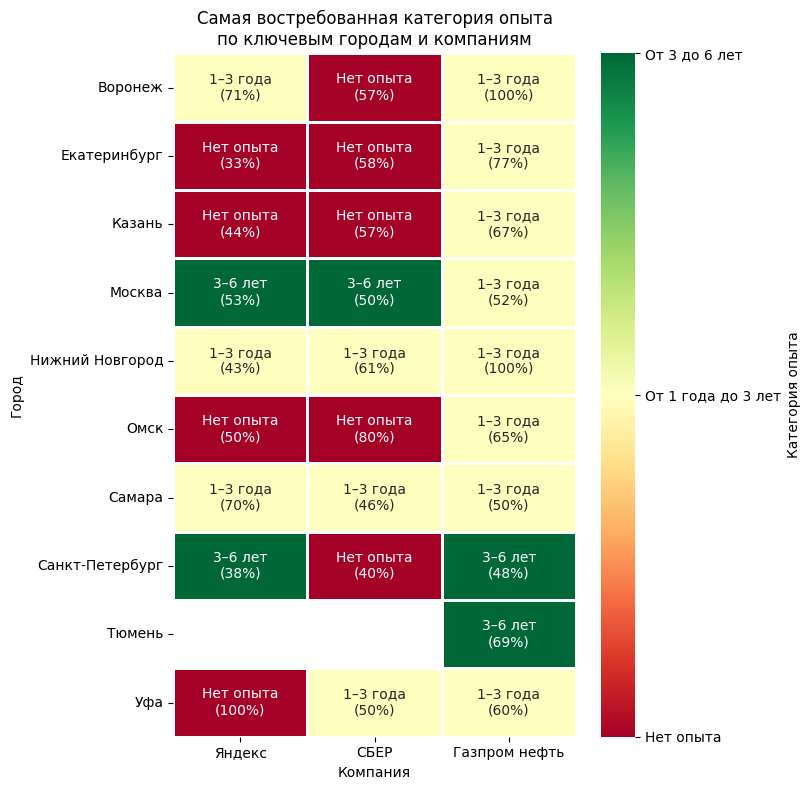

In [34]:
# Тепловая карта: самая востребованная категория опыта
experience_order = ['Нет опыта', 'От 1 года до 3 лет', 'От 3 до 6 лет', 'Более 6 лет']
df['experience'] = pd.Categorical(df['experience'], categories=experience_order, ordered=True)
df['city'] = df['city'].str.split(',').str[0].str.strip()

# Топ-5 городов
top_cities = sorted({c for comp in df['company'].unique()
                     for c in df[df['company']==comp]['city'].value_counts().head(5).index})

# Подготовка данных
heat, num = pd.DataFrame(index=top_cities, columns=df['company'].unique()), \
           pd.DataFrame(index=top_cities, columns=df['company'].unique())
short = {'Нет опыта':'Нет опыта','От 1 года до 3 лет':'1–3 года','От 3 до 6 лет':'3–6 лет','Более 6 лет':'>6 лет'}

for city in top_cities:
    for comp in df['company'].unique():
        sub = df[(df['company']==comp) & (df['city']==city)]
        if len(sub):
            cnt = sub['experience'].value_counts()
            top = cnt.idxmax()
            heat.loc[city, comp] = f"{short[top]}\n({cnt.max()/len(sub)*100:.0f}%)"
            num.loc[city, comp] = experience_order.index(top)+1
        else:
            heat.loc[city, comp], num.loc[city, comp] = '—', np.nan

# График
fig, ax = plt.subplots(figsize=(8, len(top_cities)*0.8))
sns.heatmap(num.astype(float), annot=heat.values, fmt='', cmap='RdYlGn', linewidths=1,
            cbar_kws={'label':'Категория опыта','ticks':[1,2,3,4]}, ax=ax)
ax.collections[0].colorbar.set_ticklabels(experience_order)
ax.set(title='Самая востребованная категория опыта\nпо ключевым городам и компаниям',
       xlabel='Компания', ylabel='Город')
plt.tight_layout(); plt.show()

**Выводы:**
- **Столицы vs регионы:** Москва и Санкт-Петербург - доминируют опытные, регионы - точки входа для новичков.
- **Отраслевая специфика:** Газпром нефть даже в регионах требует минимальный опыт (1–3 года), Сбер и Яндекс чаще берут кандидатов без опыта — сказывается специфика производства и массовые позиции с внутренним обучением.
- **Разные стратегии в одних городах:** В Екатеринбурге Сбер набирает новичков (58%), а Газпром нефть — специалистов с опытом (77%) — компании по-разному используют региональные рынки труда.

## **3. Структура профессиональных кластеров по компаниям**
В структуре вакансии есть поле 'professional_role', сгруппируем по нему вакансии в кластеры. Это позволит оценить каких специалистов ищут компании. Результаты визуализируем тепловой картой, чем темнее цвет, тем чаще упоминание.

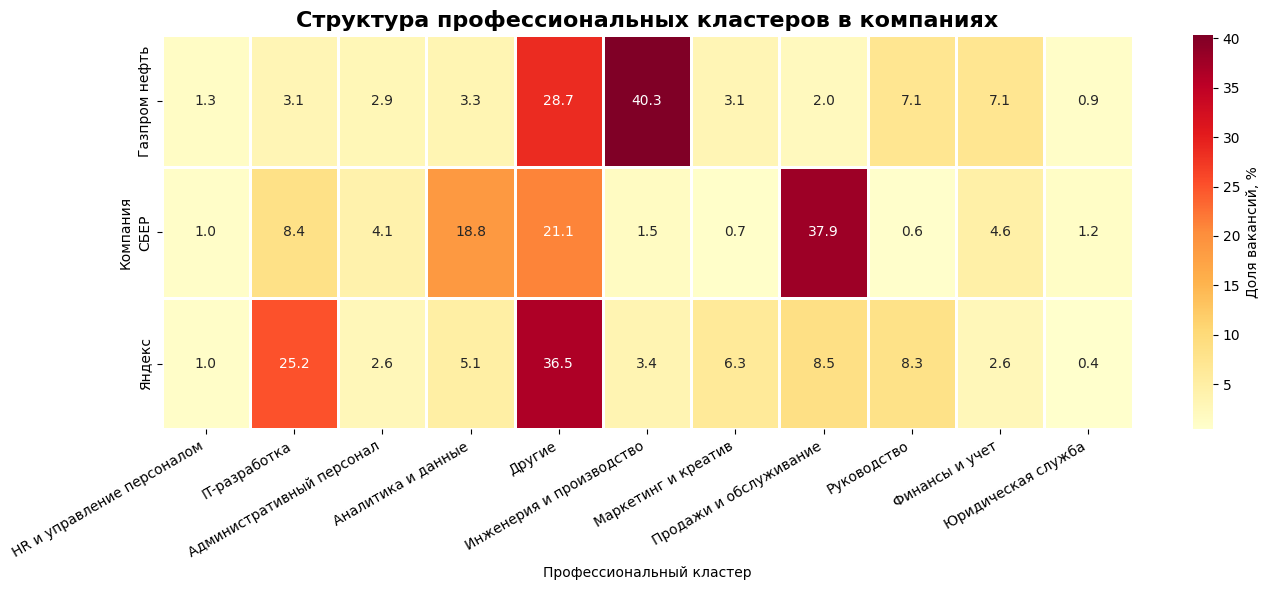

In [42]:
def assign_cluster(role):
    """Распределяет профессиональную роль по кластеру"""
    role_lower = str(role).lower()

    if any(word in role_lower for word in
           ['программист', 'разработчик', 'devops', 'тестировщик', 'qa', 'архитектор', 'data scientist',
            'дата-сайентист']):
        return 'IT-разработка'
    elif any(word in role_lower for word in
             ['аналитик', 'bi-аналитик', 'data', 'продуктовый аналитик', 'системный аналитик', 'бизнес-аналитик']):
        return 'Аналитика и данные'
    elif any(word in role_lower for word in
             ['менеджер по продажам', 'продавец', 'работе с клиентами', 'менеджер по работе с клиентами',
              'оператор call-центра']):
        return 'Продажи и обслуживание'
    elif any(word in role_lower for word in
             ['инженер', 'технолог', 'механик', 'электромонтажник', 'слесарь', 'машинист',
              'оператор производственной']):
        return 'Инженерия и производство'
    elif any(word in role_lower for word in ['маркетинг', 'pr', 'smm', 'продюсер', 'дизайнер', 'художник']):
        return 'Маркетинг и креатив'
    elif any(word in role_lower for word in ['hr', 'персонал', 'подбор', 'кадры', 'рекрутер']):
        return 'HR и управление персоналом'
    elif any(word in role_lower for word in ['финанс', 'бухгалтер', 'экономист', 'аудитор', 'казначей']):
        return 'Финансы и учет'
    elif any(word in role_lower for word in ['юрист', 'юрисконсульт', 'комплаенс']):
        return 'Юридическая служба'
    elif any(word in role_lower for word in
             ['администратор', 'секретарь', 'ассистент', 'офис-менеджер', 'делопроизводитель']):
        return 'Административный персонал'
    elif any(word in role_lower for word in ['руководитель', 'директор', 'начальник', 'заведующий']):
        return 'Руководство'
    else:
        return 'Другие'


df['professional_cluster'] = df['professional_role'].apply(assign_cluster)
# Создаем сводную таблицу
cluster_pivot = pd.crosstab(
    df['company'],
    df['professional_cluster'],
    normalize='index'
) * 100

# Тепловая карта
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=1, cbar_kws={'label': 'Доля вакансий, %'})
plt.title('Структура профессиональных кластеров в компаниях', fontsize=16, fontweight='bold')
plt.xlabel('Профессиональный кластер')
plt.ylabel('Компания')
plt.xticks(rotation=30,  ha='right')
plt.tight_layout()
plt.show()

Структура вакансий отражает бизнес-профиль компаний:
- Яндекс делает ставку на разработку, Газпром нефть — на инженеров и рабочих, Сбер — на продажи, сервис и аналитику.
- Доля категории «Другие» (21–36%) указывает на значительное число узкоспециализированных позиций, выходящих за рамки основных кластеров.


## **4. Тепловая карта бенефитов**
Переходим к ключевой части анализа - тепловая карта бенефитов

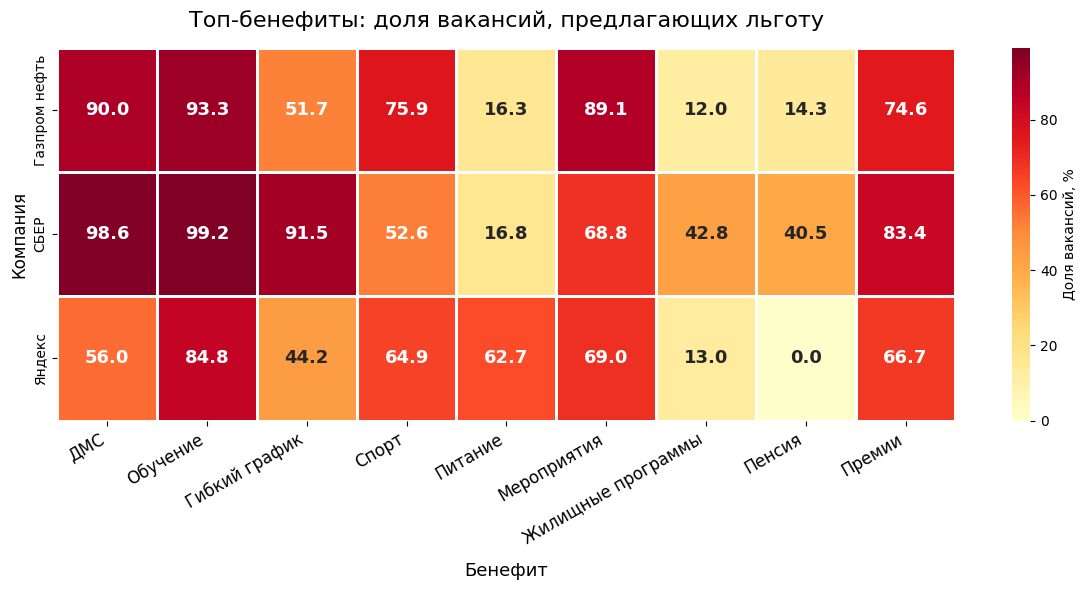

In [37]:
# Список колонок с бенефитами
benefit_cols = ['benefit_ДМС', 'benefit_Обучение', 'benefit_Гибкий график',
                'benefit_Спорт', 'benefit_Питание', 'benefit_Ивенты',
                'benefit_Жилищные программы', 'benefit_Пенсия', 'benefit_Премии']

# Переименуем для красоты графиков
benefit_names_ru = {
    'benefit_ДМС': 'ДМС',
    'benefit_Обучение': 'Обучение',
    'benefit_Гибкий график': 'Гибкий график',
    'benefit_Спорт': 'Спорт',
    'benefit_Питание': 'Питание',
    'benefit_Ивенты': 'Мероприятия',
    'benefit_Жилищные программы': 'Жилищные программы',
    'benefit_Пенсия': 'Пенсия',
    'benefit_Премии': 'Премии'
}

# Группируем по компаниям и считаем среднее - долю вакансий с бенефитом
benefit_summary = df.groupby('company')[benefit_cols].mean() * 100
benefit_summary = benefit_summary.rename(columns=benefit_names_ru)

# Строим тепловую карту
plt.figure(figsize=(12, 6))
sns.heatmap(benefit_summary, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=1, annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'label': 'Доля вакансий, %'})
plt.title('Топ-бенефиты: доля вакансий, предлагающих льготу', fontsize=16, pad=15)
plt.xlabel('Бенефит', fontsize=13, labelpad=10)
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.ylabel('Компания', fontsize=12)
plt.tight_layout()
plt.show()

Выводы:
1. Самые **популярные категории** среди всех компаний: Обучение, ДМС, Мероприятия и Премии.
2. **Сбербанк лидер** по предложениям, а Яндекс отстает, являясь лидером только в категории Питания.
3. Самые **непопулярные категории**: Жилищные программы, Пенсия и Питание. В категории Пенсия присутствует единственный результат 0% у Яндекса.
4. Гибким графиком выделяется Сбер 91,5% вакансий, в то время как у Яндекса наименьший результат 44,2%. Это интересный результат, важный для выводов.

## **5. Бенефиты по кластерам**
Построим тепловую карту бенефитов уже по кластерам, чтобы проследить связь предложений и отрасли.

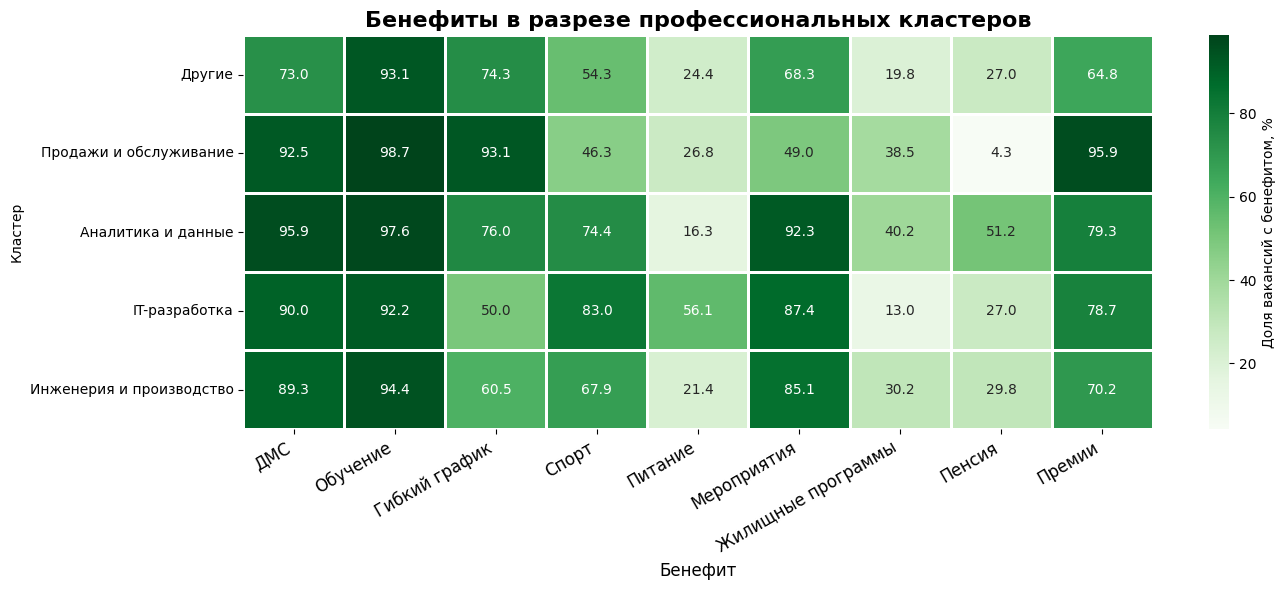

In [46]:
# Для каждого кластера считаем долю бенефитов
cluster_benefits = df.groupby('professional_cluster')[benefit_cols].mean() * 100
cluster_benefits = cluster_benefits.rename(columns=benefit_names_ru)

# Выбираем топ-5 кластеров по количеству вакансий
top_clusters = df['professional_cluster'].value_counts().head(5).index
cluster_benefits_top = cluster_benefits.loc[top_clusters]

# Тепловая карта
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_benefits_top, annot=True, fmt='.1f', cmap='Greens',
            linewidths=1, cbar_kws={'label': 'Доля вакансий с бенефитом, %'})
plt.title('Бенефиты в разрезе профессиональных кластеров', fontsize=16, fontweight='bold')
plt.xlabel('Бенефит', fontsize=12)
plt.xticks(rotation = 30, ha='right', fontsize=12)
plt.ylabel('Кластер')
plt.tight_layout()
plt.show()

**Ключевые выводы:<br>**

**1.Самые востребованные бенефиты** Обучение (от 92,2% до 98,7%) и ДМС (от 73% до 95,9%) стали практически стандартом на рынке труда.<br>

**2. Отраслевая специфика:**<br>
Продажи и обслуживание: Самый высокий показатель по премиям (95,9%), что логично для мотивации коммерческого персонала. Также здесь чаще всего предлагают обучение (98,7%).<br>
IT-разработка: Выделяется самым высоким уровнем обеспечения питанием (56,1%) по сравнению с другими группами. При этом гибкий график (50%) встречается реже, чем у аналитиков или в категории «Другие».<br>
Аналитика и данные: Лидирует по предоставлению ДМС (95,9%), спорта (74,4%) и корпоративных мероприятий (92,3%).<br>
Инженерия и производство: По многим показателям (ДМС, обучение, мероприятия) демонстрирует стабильно высокие цифры, близкие к IT-сфере.<br>

**3. Редкие и непопулярные льготы:**<br>
Пенсионные программы и жилищные программы: Это самые редкие бенефиты. Особенно низкий интерес к пенсиям в продажах (всего 4,3%).<br>
Питание: Несмотря на наличие в соцпакетах, его доля остается сравнительно низкой (от 16,3% до 26,8%), за исключением IT-сектора.<br>

**4. Общий тренд**<br>
Работодатели делают основной упор на профессиональное развитие и здоровье, в то время как долгосрочные программы  и повседневные расходы предлагаются значительно реже.

## **Финальные выводы и стратегическое резюме**

Проведенный анализ 2039 вакансий трех работодателей (Яндекса, Сбера и Газпром нефти) позволил не просто сравнить их по формальным признакам, а выявить фундаментальную связь между бизнес-моделью компании и её стратегией найма.

**Ключевой вывод:**
Портрет идеального кандидата и структура предложения труда радикально отличаются. Компании не конкурируют за абстрактного человека, а выстраивают свою уникальную систему привлечения и EVP под конкретные задачи.

---

### **Стратегические профили компаний**

#### **1. Яндекс — «Магнит для опытных технарей»**
*   **Фокус**: IT-разработка (25.2% вакансий).
*   **Стратегия**: Охота за middle-специалистами (3-6 лет опыта) с максимальными зарплатами. Senior-позиции часто предполагают индивидуальные условия.
*   **Особенности бенефитов**: Лидер по предоставлению питания (56.1% в IT-кластере), что создает образ технологичного офиса с высоким уровнем комфорта. При этом парадоксально уступает Сберу по гибкому графику и премиям, полагаясь на силу бренда и сложность задач.

#### **2. Газпром нефть — «Кузница кадров и удержание»**
*   **Фокус**: Инженерия и производство (40.3% вакансий).
*   **Стратегия**: Лучшие условия для новичков и специалистов с опытом 1-3 года. Практически отсутствуют открытые вакансии для senior-уровня, что указывает на мощную систему внутреннего кадрового резерва и долгосрочного выращивания талантов.
*   **Особенности бенефитов**: Стабильный, но не самый гибкий соцпакет, ориентированный на фундаментальные потребности (ДМС, спорт), а не на сиюминутную мотивацию.

#### **3. Сбербанк — «Империя лояльности и гибкости»**
*   **Фокус**: Продажи и обслуживание (37.9%).
*   **Стратегия**: Ставка на масштаб и гибкость. Лидер по привлечению новичков без опыта, которых, очевидно, готовы обучать. Абсолютный лидер по гибкому графику (91.5%) и премиям (83.4%), что делает его самым привлекательным для ценящих баланс работы и личный жизни вместе с прямой финансовой мотивацией.
*   **Особенности бенефитов**: Самый сбалансированный EVP на рынке, закрывающий практически все потребности от здоровья до спорта и мероприятий.

---

### **Общие тренды рынка**

1.  **Обучение как базовый минимум**: Доля вакансий с этим бенефитом достигает 84-99%, что говорит о превращении в обязательное условие для работы в крупной компании.
2.  **Долгосрочные программы — аутсайдеры**: Пенсионные и жилищные программы практически не представлены, уступая место быстрым и понятным льготам вроде ДМС и премий. Это отражает фокус на текущем потреблении, а не на построении долгосрочных отношений через соцпакет.
3.  **Регионы как точка входа**: За пределами Москвы и Петербурга компании активнее нанимают новичков, превращая региональные офисы в инкубаторы талантов. Особенно это заметно у Сбера.

---

### **Практическая ценность для HR-специалистов**

*   **Для Яндекса**: Усилить позиционирование в части гибкости и долгосрочной мотивации, чтобы успешнее конкурировать за мидлов со Сбером. Активнее пиарить уникальные условия, например, питание.
*   **Для Газпром нефти**: Использовать свои сильные стартовые позиции для привлечения молодых инженеров, делая акцент на карьерном росте внутри компании. Возможно, стоит подсветить редкие, но важные долгосрочные программы как жилье и пенсия, чтобы выделиться.
*   **Для Сбера**: Такая гибкость и масштаб — это мощный актив. Дальше можно сегментировать EVP под разные профессиональные кластеры для точечного усиления HR-бренда.

Данный анализ позволяет перейти от интуитивного к строго data-driven подходу в формировании ценностного предложения сотрудникам.

## SQL-срез
Дополнительный блок, использующий те же данные, но агрегаты считаются на стороне SQLite. <br>
Запросы лежат в `sql/queries/`. Проверяется, что SQL-слой дает осмысленный результат, согласуясь с анализом выше.

In [4]:
import sqlite3
from pathlib import Path

project_root = Path.cwd().parent
DB_PATH = project_root / "data" / "db" / "hr_brand.sqlite"
QUERIES_DIR = project_root / "sql" / "queries"
conn = sqlite3.connect(DB_PATH)

def run_query(path):
    """Читаем .sql файл и возращаем DataFrame"""
    sql = Path(path).read_text(encoding='utf-8')
    return pd.read_sql(sql,conn)

Запрос 1

In [16]:
top_cities = run_query(QUERIES_DIR/'01_top_cities.sql')
top_cities.head(20)

,company,city,vacancies_count
0,Газпром нефть,Санкт-Петербург,161
1,Газпром нефть,Омск,97
2,Газпром нефть,Москва,83
3,Газпром нефть,Уфа,25
4,Газпром нефть,Тюмень,16
5,Газпром нефть,Новосибирск,13
6,Газпром нефть,Екатеринбург,13
7,Газпром нефть,Челябинск,8
8,Газпром нефть,Пермь,7
9,Газпром нефть,Самара,4


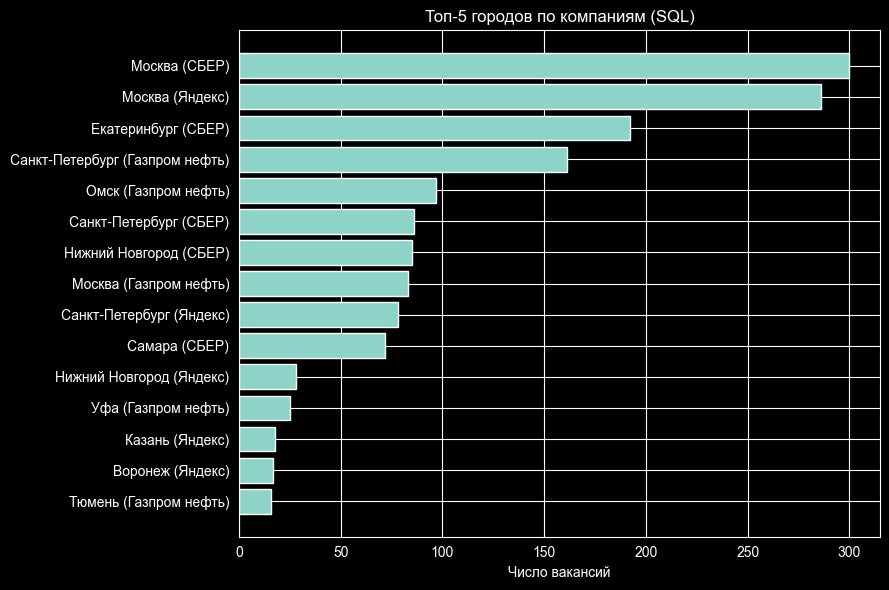

In [32]:
top = (top_cities
       .sort_values("vacancies_count", ascending=False)
       .groupby("company")
       .head(5))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["city"] + " (" + top["company"] + ")", top["vacancies_count"])
ax.set_xlabel("Число вакансий")
ax.set_title("Топ-5 городов по компаниям (SQL)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Запрос 2

In [29]:
sal_exp = run_query(QUERIES_DIR/'02_salary_by_experience.sql')
sal_exp.head(20)

,company,experience,vacancies_count,avg_mid_salary,avg_salary_from,avg_salary_to
0,Газпром нефть,Нет опыта,7,82700.0,77429.0,89000.0
1,Газпром нефть,От 1 года до 3 лет,66,130663.0,117392.0,134076.0
2,Газпром нефть,От 3 до 6 лет,11,95000.0,100000.0,110000.0
3,СБЕР,Более 6 лет,2,NaN,95000.0,250000.0
4,СБЕР,Нет опыта,366,72581.0,79857.0,79709.0
5,СБЕР,От 1 года до 3 лет,244,89417.0,102276.0,132538.0
6,СБЕР,От 3 до 6 лет,16,NaN,141989.0,380000.0
7,Яндекс,Более 6 лет,1,375000.0,250000.0,500000.0
8,Яндекс,Нет опыта,41,63395.0,46527.0,57179.0
9,Яндекс,От 1 года до 3 лет,59,71139.0,58309.0,76265.0


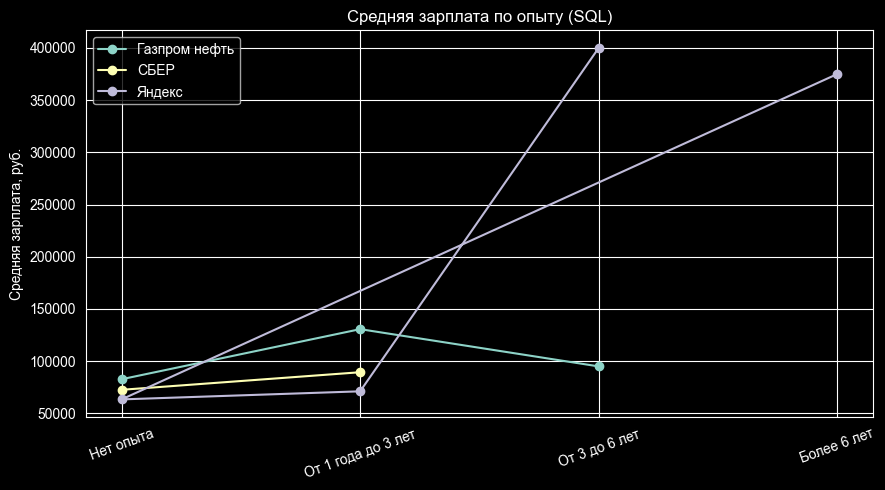

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
for comp, sub in sal_exp.groupby("company"):
    ax.plot(sub["experience"], sub["avg_mid_salary"], marker="o", label=comp)
ax.set_ylabel("Средняя зарплата, руб.")
ax.set_title("Средняя зарплата по опыту (SQL)")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Запрос 3

In [22]:
ben_share = run_query(QUERIES_DIR/'03_benefits_share.sql')
ben_share.head(20)

,company,total_vacancies,dms_pct,training_pct,sport_pct,food_pct,flexible_pct,bonus_pct
0,Газпром нефть,449,90.0,93.3,75.9,16.3,51.7,74.6
1,СБЕР,1097,98.6,99.2,52.6,16.8,91.5,83.4
2,Яндекс,493,56.0,84.8,64.9,62.7,44.2,66.7


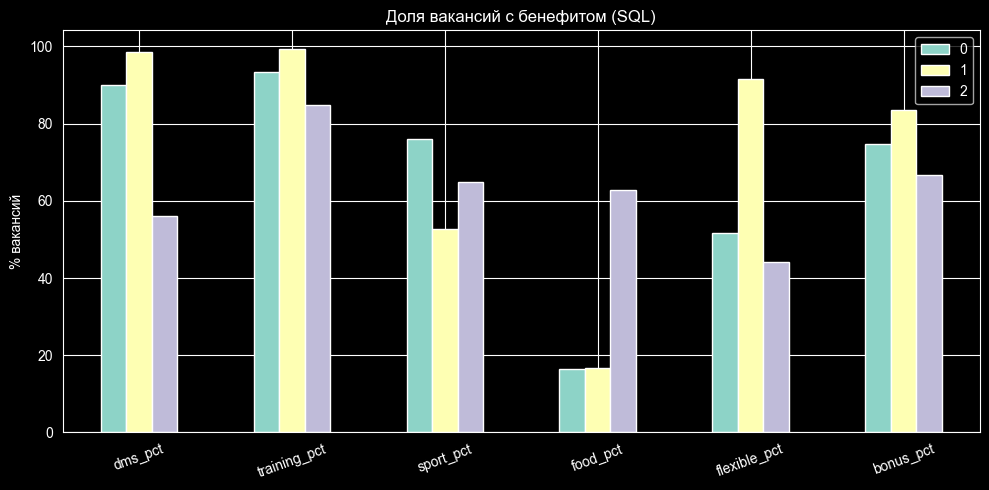

In [21]:
cols = ["dms_pct", "training_pct", "sport_pct",
        "food_pct", "flexible_pct", "bonus_pct"]

ben_share[cols].T.plot(kind="bar", figsize=(10, 5))
plt.ylabel("% вакансий")
plt.title("Доля вакансий с бенефитом (SQL)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Запрос 4

In [23]:
role_ranking = run_query(QUERIES_DIR/'04_role_ranking.sql')
role_ranking.head(20)

,company,professional_role,cnt,rnk
0,Газпром нефть,Другое,48,1
1,Газпром нефть,Электромонтажник,43,2
2,Газпром нефть,Оператор производственной линии,26,3
3,СБЕР,"Менеджер по продажам, менеджер по работе с кли...",339,1
4,СБЕР,"Финансовый аналитик, инвестиционный аналитик",105,2
5,СБЕР,Аналитик,97,3
6,Яндекс,"Программист, разработчик",110,1
7,Яндекс,Другое,76,2
8,Яндекс,"Менеджер по продажам, менеджер по работе с кли...",41,3


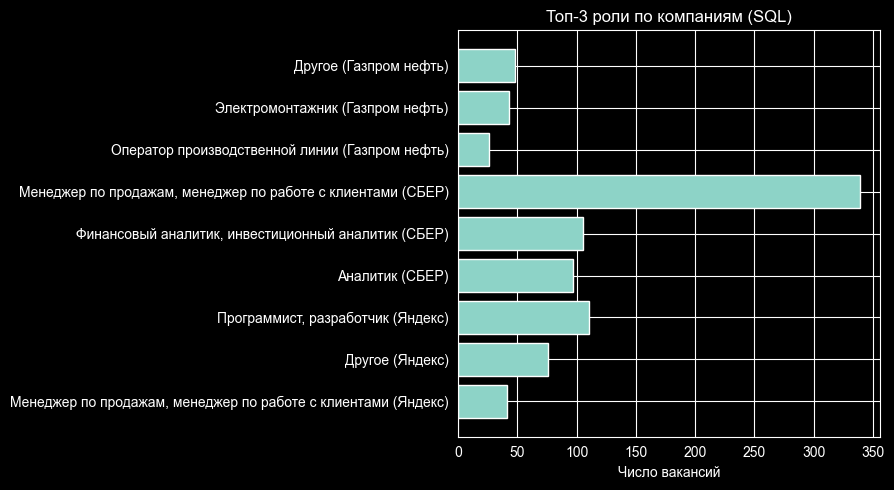

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(role_ranking["professional_role"] + " (" + role_ranking["company"] + ")", role_ranking["cnt"])
ax.set_xlabel("Число вакансий")
ax.set_title("Топ-3 роли по компаниям (SQL)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Запрос 5

In [25]:
sal_mean = run_query(QUERIES_DIR/'05_salary_vs_mean.sql')
sal_mean.head(20)

,company,professional_role,vacancies_count,avg_salary,company_avg,diff
0,Газпром нефть,Оператор производственной линии,15,81917.0,57577.0,24339.0
1,Газпром нефть,"Слесарь, сантехник",13,64423.0,57577.0,6846.0
2,Газпром нефть,Электромонтажник,29,59129.0,57577.0,1552.0
3,Газпром нефть,Бухгалтер,5,27000.0,57577.0,-30577.0
4,СБЕР,"Финансовый аналитик, инвестиционный аналитик",46,63758.0,46268.0,17490.0
5,СБЕР,Финансовый контролер,15,56617.0,46268.0,10349.0
6,СБЕР,Специалист технической поддержки,7,54214.0,46268.0,7946.0
7,СБЕР,Менеджер по работе с партнерами,7,52357.0,46268.0,6089.0
8,СБЕР,"Менеджер по продажам, менеджер по работе с кли...",316,44973.0,46268.0,-1295.0
9,СБЕР,Другое,30,44965.0,46268.0,-1303.0


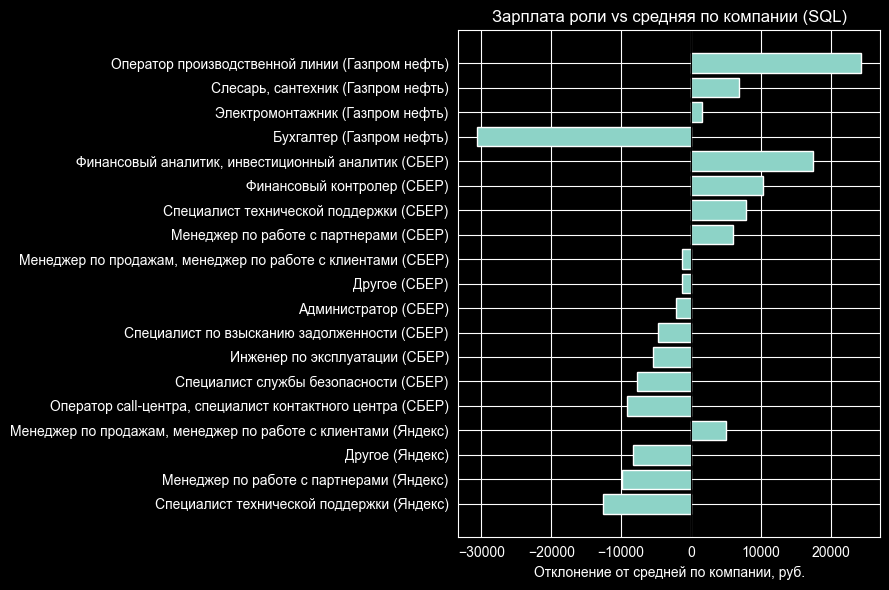

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sal_mean["professional_role"] + " (" + sal_mean["company"] + ")", sal_mean["diff"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Отклонение от средней по компании, руб.")
ax.set_title("Зарплата роли vs средняя по компании (SQL)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Запрос 6

In [27]:
exp_dist = run_query(QUERIES_DIR/'06_experience_distribution.sql')
exp_dist.head(20)

,company,experience,vacancies_count,pct_within_company
0,Газпром нефть,От 1 года до 3 лет,247,55.0
1,Газпром нефть,От 3 до 6 лет,167,37.2
2,Газпром нефть,Более 6 лет,19,4.2
3,Газпром нефть,Нет опыта,16,3.6
4,СБЕР,От 1 года до 3 лет,434,39.6
5,СБЕР,Нет опыта,392,35.7
6,СБЕР,От 3 до 6 лет,225,20.5
7,СБЕР,Более 6 лет,46,4.2
8,Яндекс,От 3 до 6 лет,193,39.1
9,Яндекс,От 1 года до 3 лет,128,26.0


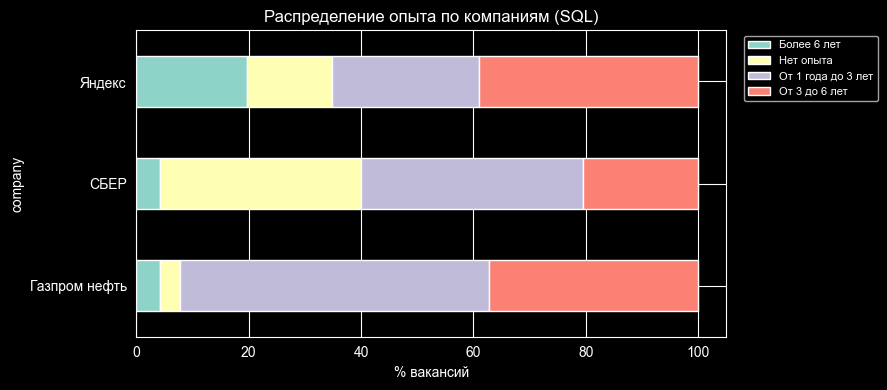

In [28]:
pivot = exp_dist.pivot(index="company", columns="experience",
                 values="pct_within_company").fillna(0)

pivot.plot(kind="barh", stacked=True, figsize=(9, 4))
plt.xlabel("% вакансий")
plt.title("Распределение опыта по компаниям (SQL)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Сверка с pandas-анализом

- `06_experience_distribution.sql` — доли опыта по компаниям совпадают
  с графиком распределения опыта выше.
- `03_benefits_share.sql` — гибкий график у Сбера ~91%, премии ~83% —
  как в основном анализе бенефитов.
- `02_salary_by_experience.sql` — тренд «чем больше опыта, тем выше
  зарплата» подтверждается по всем трём компаниям.
- `05_salary_vs_mean.sql` — показывает, какие роли внутри компании
  платят выше/ниже среднего (новый срез, в pandas такого не было).

Расхождений с основным анализом нет. SQL-слой даёт те же результаты,
что pandas, и может использоваться как альтернативный инструмент
для быстрых срезов.